### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [83]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import matplotlib.colors as mcolors


In [54]:
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)
matplotlib.rcParams['figure.dpi'] = 300

In [55]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image
import pydotplus

from sklearn.tree import export_graphviz

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [56]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [57]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

Tamaño del dataset: 18 filas, 5 columnas
Categorías de P_HABITABLE y conteo de ejemplos:
P_HABITABLE
0    10
1     8
Name: count, dtype: int64


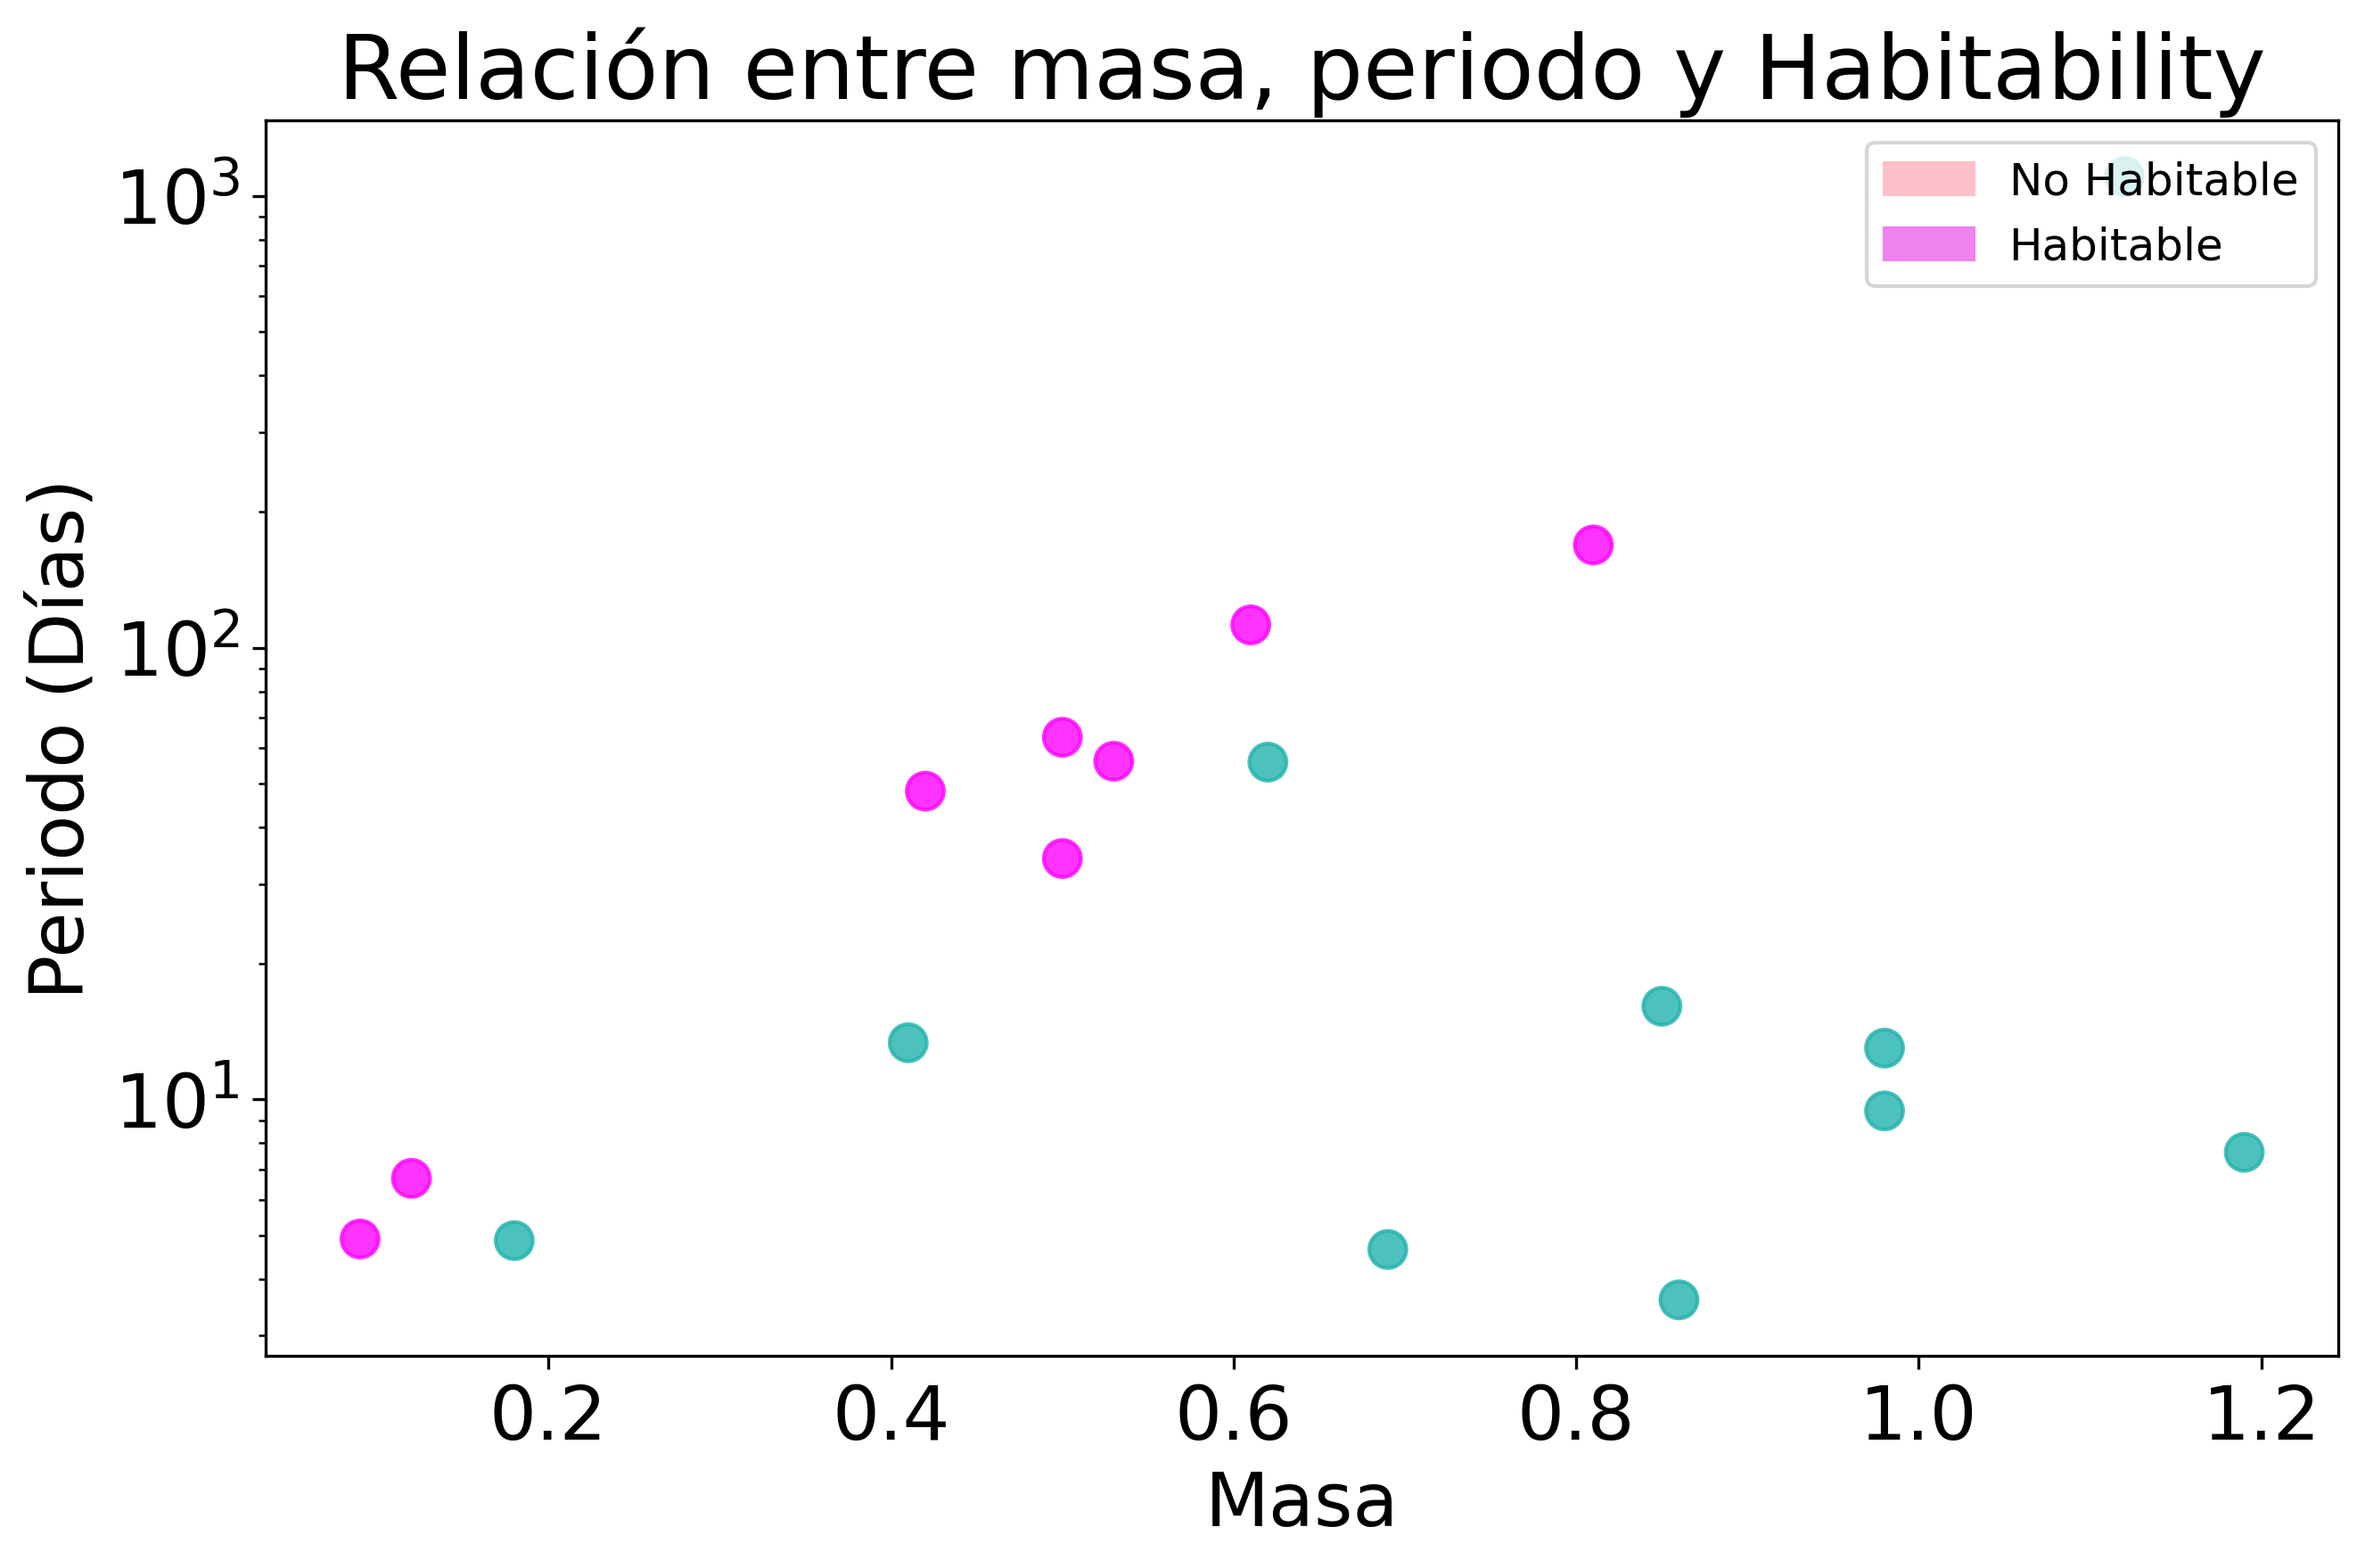

In [58]:
# Tamaño del dataset
print(f"Tamaño del dataset: {LearningSet.shape[0]} filas, {LearningSet.shape[1]} columnas")

# Ejemplos en cada categoría
print("Categorías de P_HABITABLE y conteo de ejemplos:")
print(LearningSet['P_HABITABLE'].value_counts())

# Visualización
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

plt.figure(figsize=(10, 6))

scatter = plt.scatter(LearningSet['S_MASS'], LearningSet['P_PERIOD'],
                      c=LearningSet['P_HABITABLE'], cmap=cmap, s=100, alpha=0.8)

plt.yscale('log')
plt.xlabel('Masa')
plt.ylabel('Periodo (Días)')
plt.title('Relación entre masa, periodo y Habitability')
bluepatch = mpatches.Patch(color='pink', label='No Habitable')
magentapatch = mpatches.Patch(color='violet', label='Habitable')
plt.legend(handles=[bluepatch, magentapatch], loc='upper right', fontsize=12)

plt.show()





Tamaño del dataset: 18 filas, 5 columnas
         P_NAME  S_MASS    P_PERIOD  P_DISTANCE  P_HABITABLE
0  Kepler-736 b    0.86    3.601472    0.043718            0
1  Kepler-636 b    0.85   16.080661    0.118082            0
2  Kepler-887 c    1.19    7.638460    0.080420            0
3  Kepler-442 b    0.61  112.305300    0.409327            1
4  Kepler-772 b    0.98   12.992073    0.107408            0
<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_NAME       18 non-null     object 
 1   S_MASS       18 non-null     float64
 2   P_PERIOD     18 non-null     float64
 3   P_DISTANCE   18 non-null     float64
 4   P_HABITABLE  18 non-null     int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 864.0+ bytes
None
P_HABITABLE
0    10
1     8
Name: count, dtype: int64


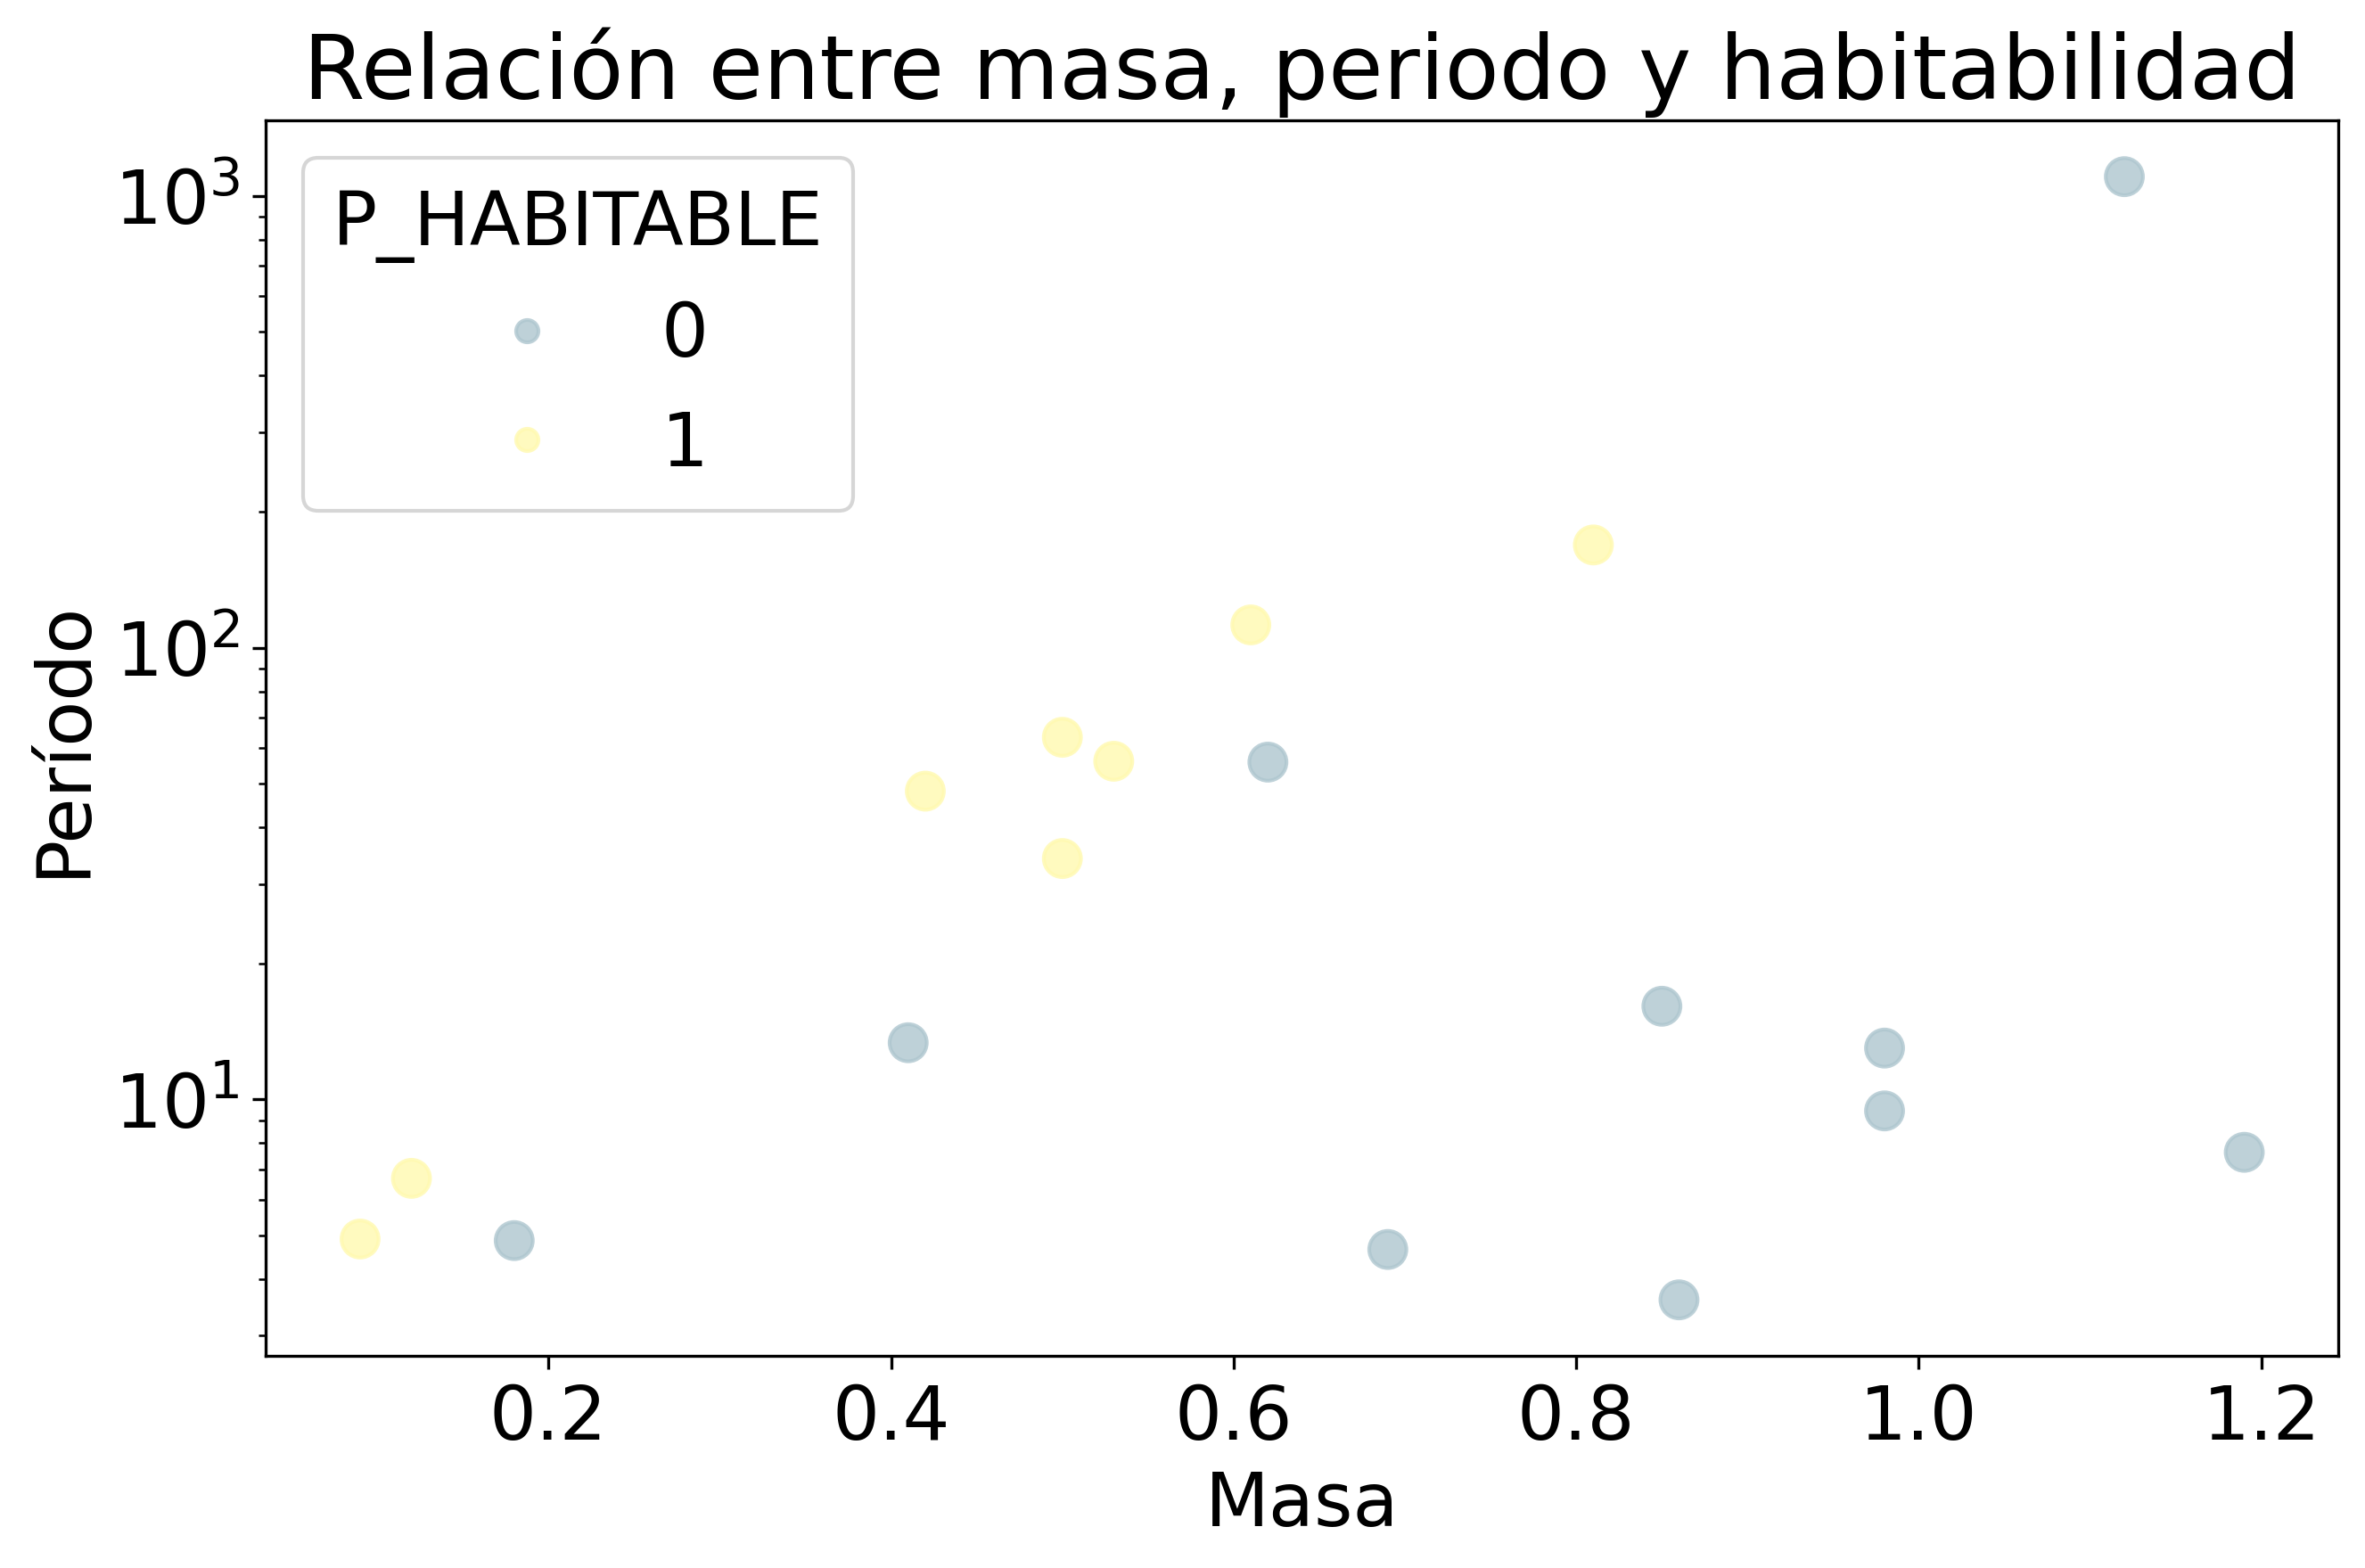

In [86]:
# Tamaño del dataset
print(f"Tamaño del dataset: {LearningSet.shape[0]} filas, {LearningSet.shape[1]} columnas")

# Revisión
print(LearningSet.head())
print(LearningSet.info())

# Categorías
print(LearningSet['P_HABITABLE'].value_counts())

# Gráfico
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    LearningSet['S_MASS'],
    LearningSet['P_PERIOD'],
    c=LearningSet['P_HABITABLE'],
    cmap = mcolors.LinearSegmentedColormap.from_list(
    "",
    ["#AEC6CF", "#FFF9B0"]),
    s=100,
    alpha=0.8)

plt.yscale('log')
plt.xlabel('Masa')
plt.ylabel('Período')
plt.title('Relación entre masa, periodo y habitabilidad')

plt.legend(*scatter.legend_elements(), title="P_HABITABLE")

plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**


No me parece que la separación entre las clases de planetas sea clara. Ambas categorías lucen mezcladas sin presentar frontera tal que las haga distinguirse, por lo que asumo deberemos complejizar el modelo.


### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [61]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [62]:
TrainSet =  LearningSet.iloc[:13,:]

TestSet = LearningSet.iloc[13:,:]

In [63]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [64]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [65]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [66]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [67]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba

ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [68]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [69]:
ytrain

,P_HABITABLE
0,0
1,0
2,0
3,1
4,0
5,1
6,0
7,1
8,0
9,1


### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [70]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión


In [71]:
dt_model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros

dt_model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

DecisionTreeClassifier(random_state=3)

### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/)

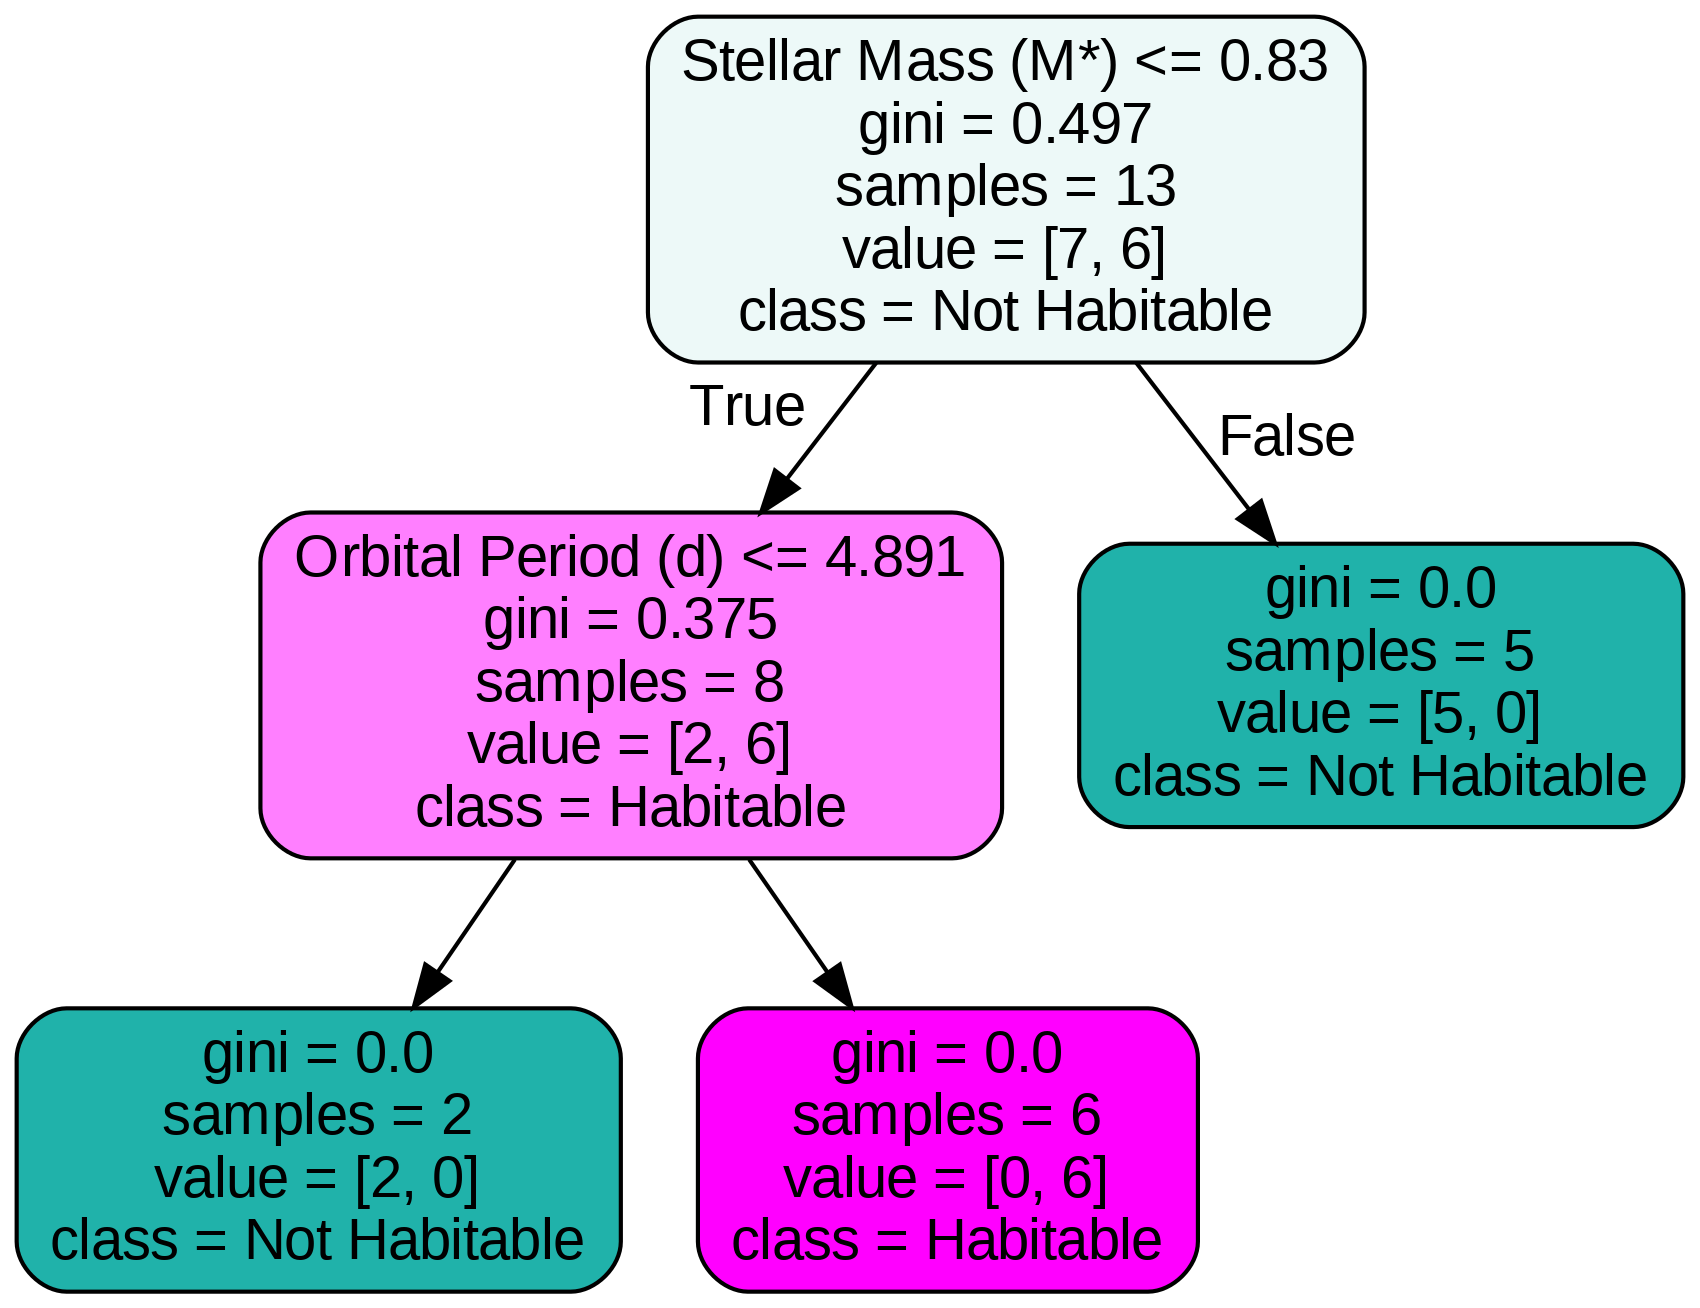

In [72]:
dot_data = StringIO()
export_graphviz(
            dt_model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]

        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

### Visualización de sklearn

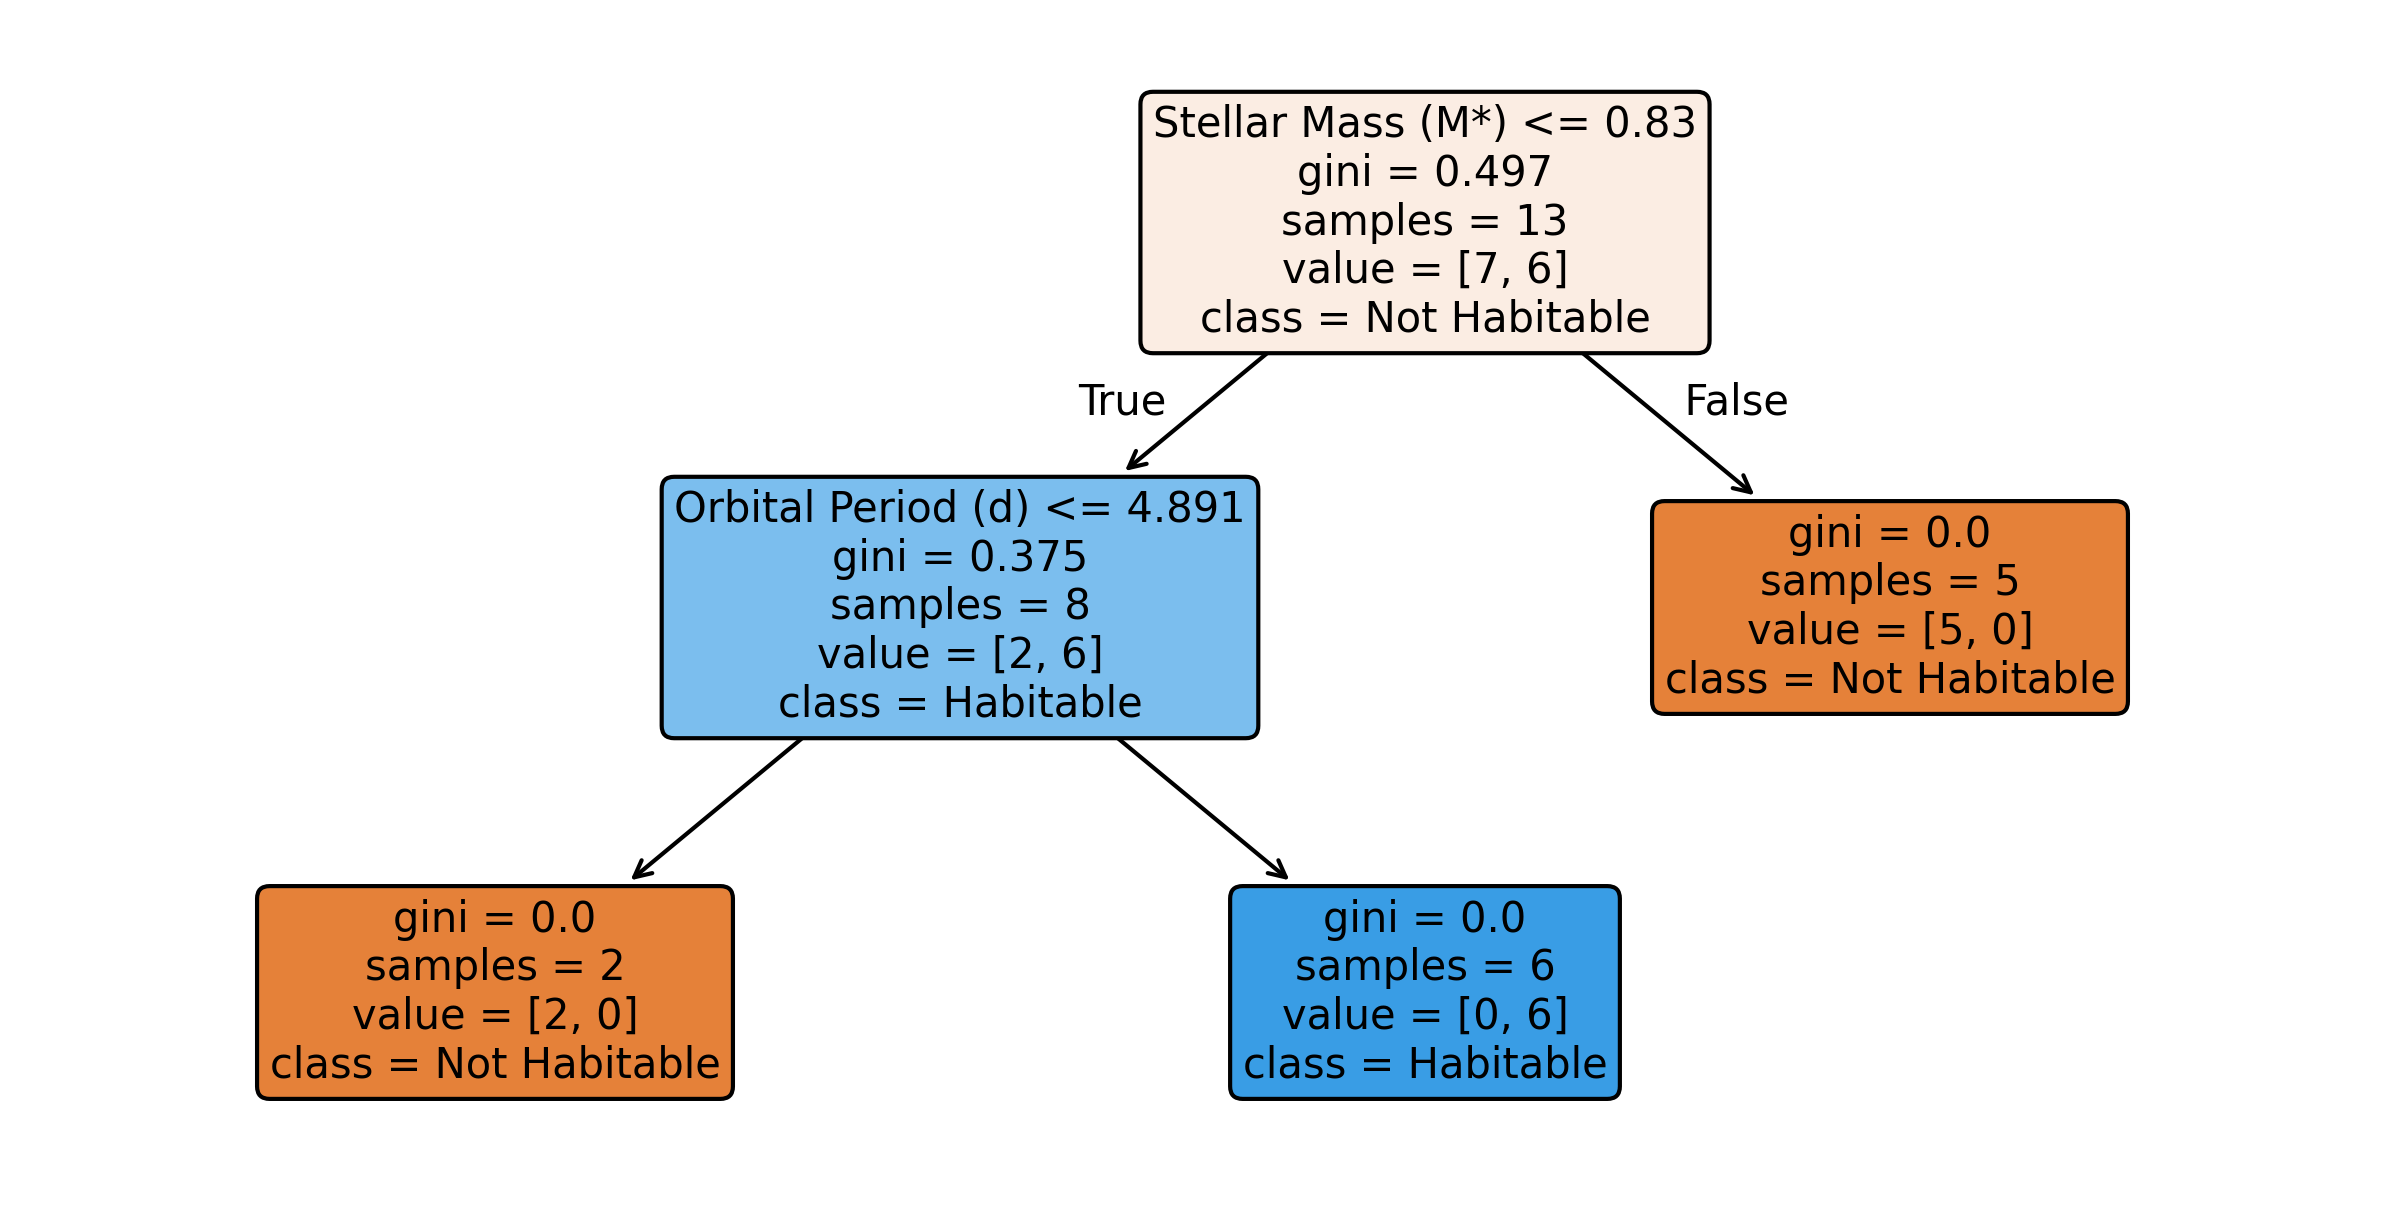

In [73]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(dt_model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

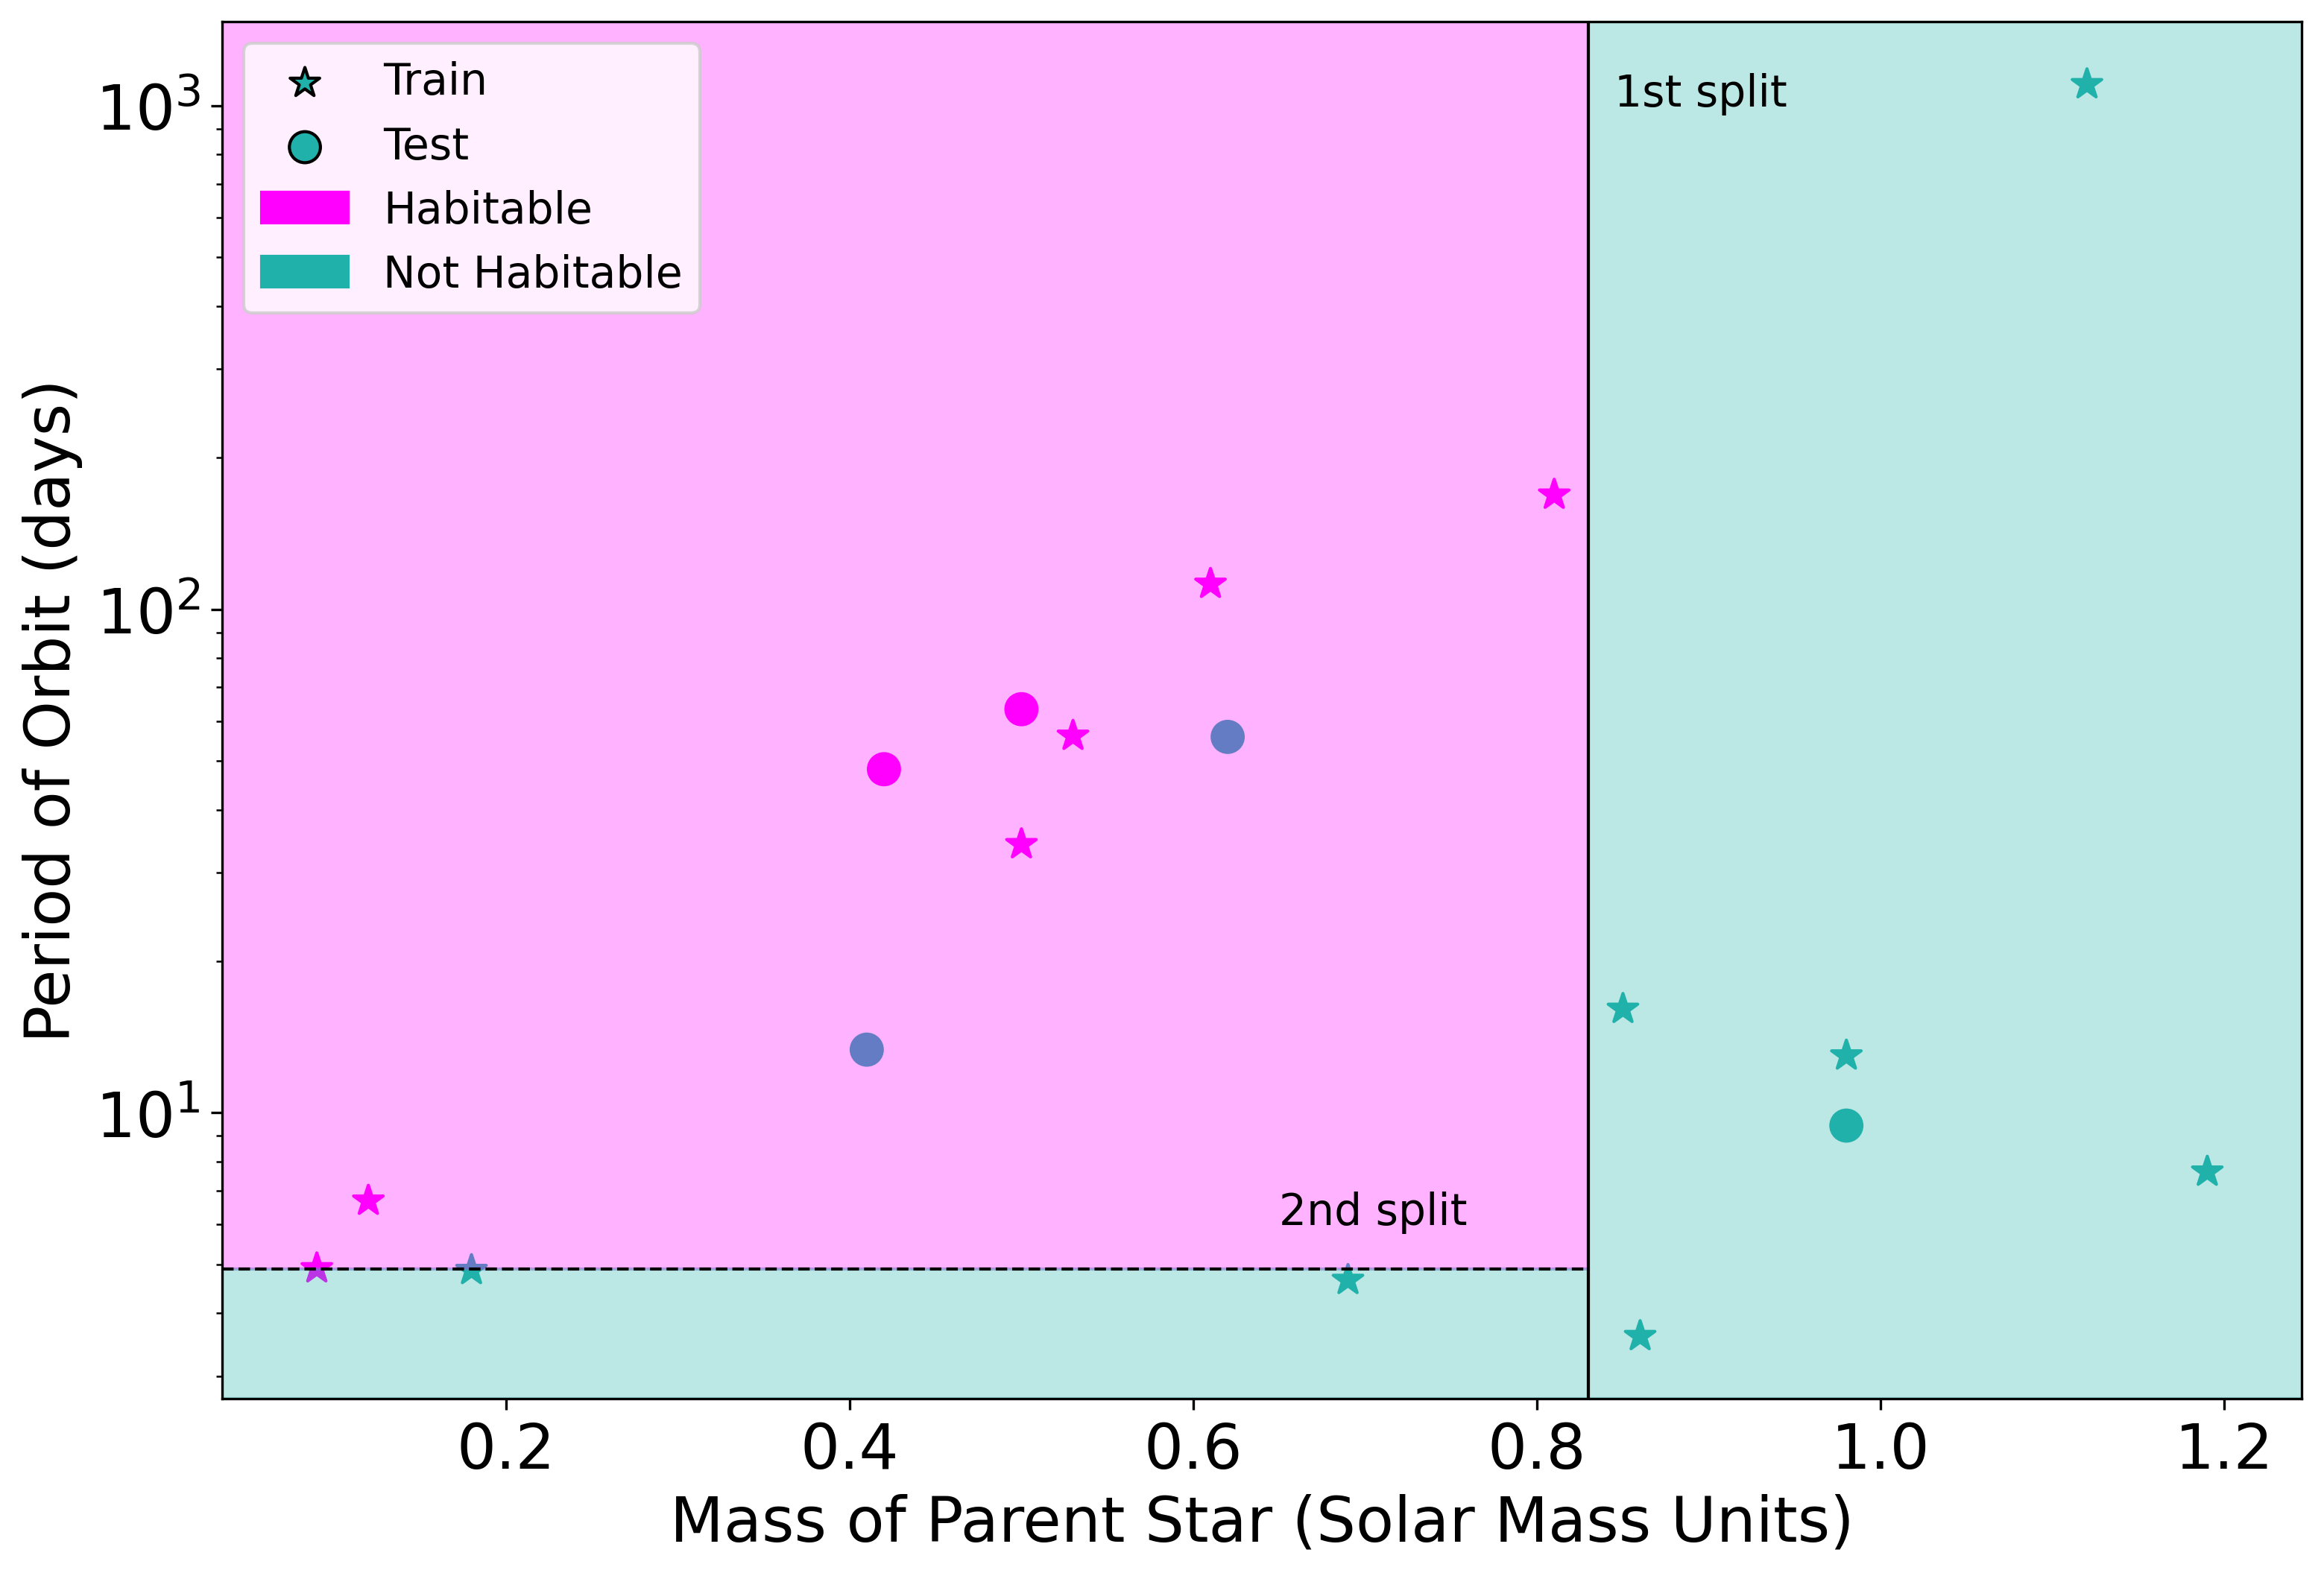

In [74]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)

plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1],
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0],
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);

### Pregunta
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?


A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

In [75]:
import sklearn.metrics as metrics

# Calculate accuracy for the training set (Decision Tree)
train_accuracy = metrics.accuracy_score(ytrain, dt_model.predict(Xtrain))
print(f"Accuracy en el set de entrenamiento (Decision Tree): {train_accuracy:.2%}")

# Generate predictions for the test set (Decision Tree)
ypred_dt = dt_model.predict(Xtest)
# Calculate accuracy for the test set (Decision Tree)
test_accuracy = metrics.accuracy_score(ytest, ypred_dt)
print(f"Accuracy en el set de prueba (Decision Tree): {test_accuracy:.2%}")

Accuracy en el set de entrenamiento (Decision Tree): 100.00%
Accuracy en el set de prueba (Decision Tree): 60.00%


### usando la métricas de sklearn, podemos encontrar el accuracy


In [76]:
import sklearn.metrics as metrics


In [77]:
ypred = dt_model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [78]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [79]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [80]:
metrics.accuracy_score(ytrain, dt_model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?
2. ¿Qué ocurre en el conjunto de prueba?
3. ¿Qué variable aparece en la raíz del árbol?
4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?


1. El árbol logra clasificar perfectamente los datos de entrenamiento, alcanzando un 100.00% de accuracy. Esto indica que el modelo predice correctamente la habitabilidad para todos los planetas en ese conjunto.

2. Sin embargo, en el conjunto de prueba el accuracy baja a 60.00%. Esta diferencia respecto al entrenamiento sugiere la presencia de sobreajuste (overfitting), ya que el modelo aprendió demasiado bien los patrones específicos del entrenamiento, pero no logra generalizar correctamente a nuevos datos.

3. La variable ubicada en la raíz del árbol es 'Stellar Mass (M)'.

4. Considerando que el dataset es pequeño, el árbol parece bastante profundo. El hecho de alcanzar un 100% de accuracy en entrenamiento mediante varias divisiones nos sugiere que el modelo pudo haber memorizado los datos en lugar de capturar patrones generales.

### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [81]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:]

TestSet2 = LearningSet.iloc[:5,:]

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

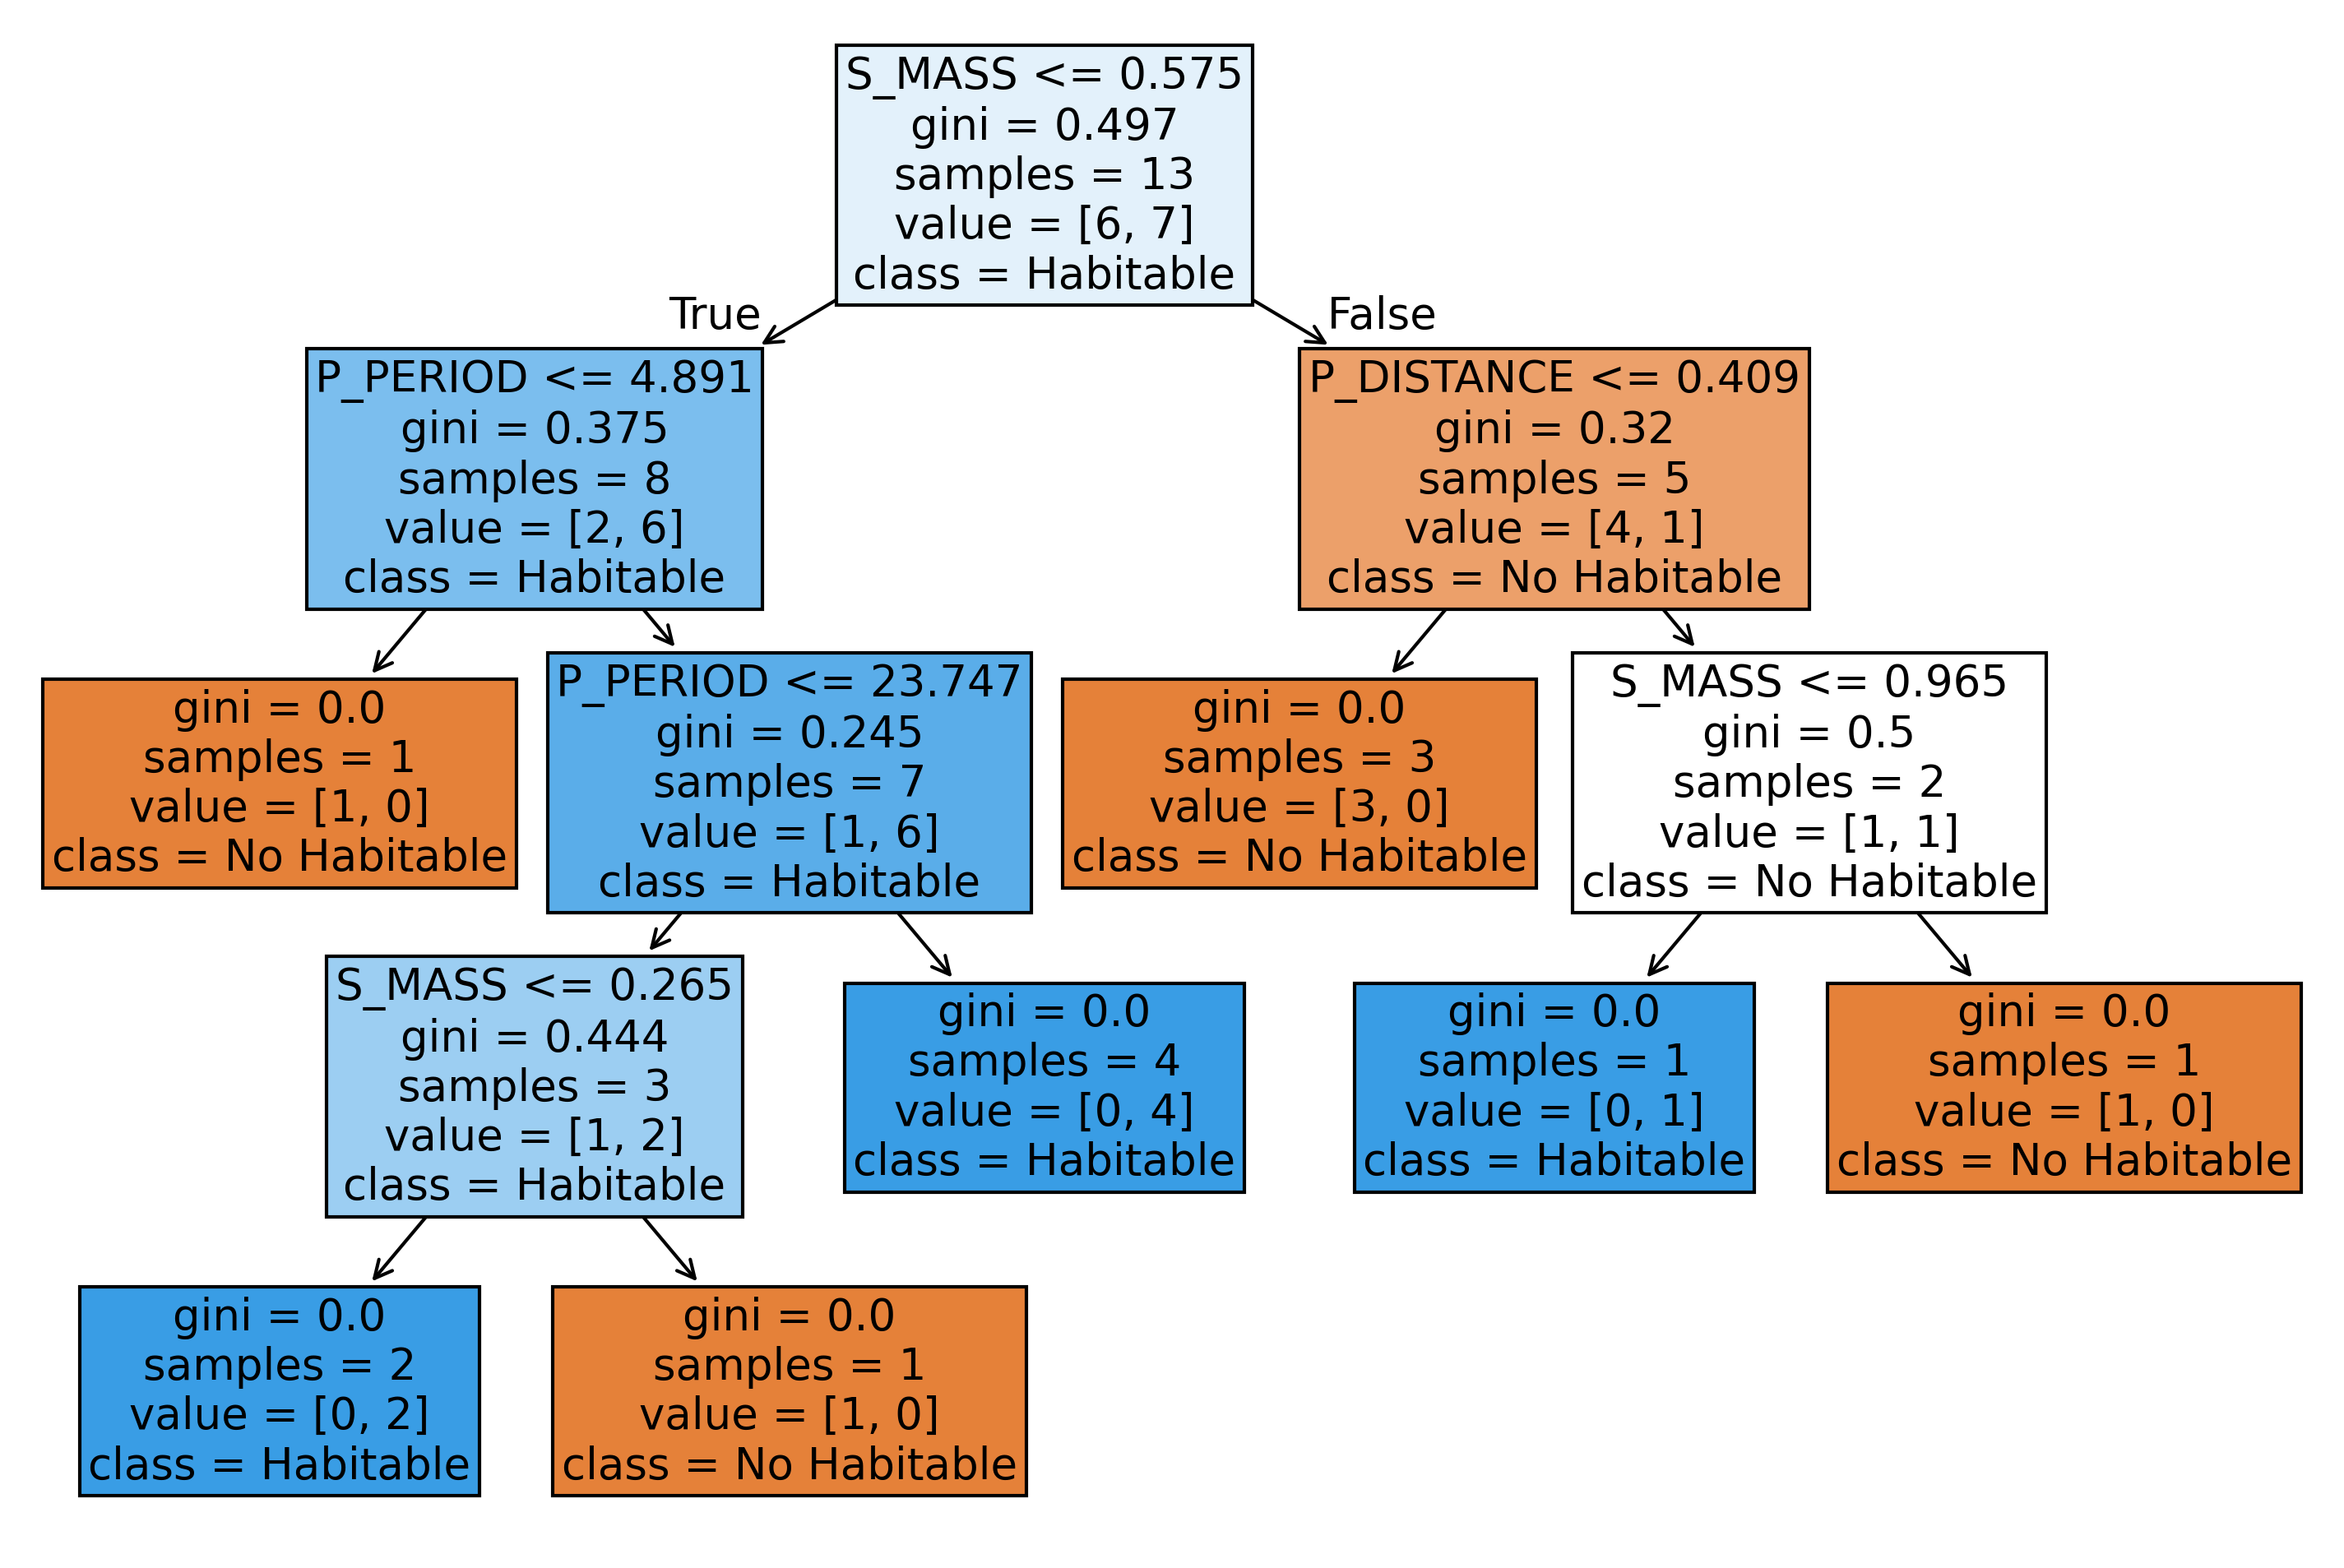

Accuracy entrenamiento: 100.00%
Accuracy prueba: 100.00%


In [89]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


# Definimos x e y
Xtrain2 = TrainSet2[['S_MASS', 'P_PERIOD', 'P_DISTANCE']]
ytrain2 = TrainSet2['P_HABITABLE']


Xtest2 = TestSet2[['S_MASS', 'P_PERIOD', 'P_DISTANCE']]
ytest2 = TestSet2['P_HABITABLE']

# Inicializamos modelo
model2 = DecisionTreeClassifier(random_state=3)

# Entrenamos modelo
model2.fit(Xtrain2, ytrain2)

# Visualizamos
plt.figure(figsize=(12, 8))
plot_tree(
    model2,
    feature_names=Xtrain2.columns,
    class_names=['No Habitable', 'Habitable'],
    filled=True)
plt.show()

# Predecimos
ytrain_pred = model2.predict(Xtrain2)
ytest_pred = model2.predict(Xtest2)

# Accuracy
acc_train = accuracy_score(ytrain2, ytrain_pred)
acc_test = accuracy_score(ytest2, ytest_pred)

print(f"Accuracy entrenamiento: {acc_train:.2%}")
print(f"Accuracy prueba: {acc_test:.2%}")

### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento?

- ¿Y en el conjunto de prueba?

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?


### 1. Comparación de árboles  
El árbol inicial utiliza `S_MASS` como raíz y obtiene 100% de accuracy en entrenamiento y 60% en prueba, mientras que el segundo árbol utiliza `P_PERIOD` como raíz y alcanza 100% tanto en entrenamiento como en prueba. La principal diferencia está en la variable raíz y en el mejor rendimiento del segundo modelo en el conjunto de prueba.

### 2. Accuracy en entrenamiento  
El accuracy es 100%

### 3. Accuracy en prueba  
El accuracy es 100%

### 4. ¿Es mejor este árbol?  
No necesariamente, el conjunto de prueba es muy pequeño, por lo que el resultado puede deberse al azar.

### Conclusiones

- Que puede concluir respecto a al ejercicio?

- Cambian los resultados dependiendo del set de datos que utilizamos?

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

### Conclusiones

- Los Árboles de decisión pueden sobreajustarse fácilmente y son sensibles a cómo se dividen los datos, por lo que sus resultados pueden ser muy variables.  

- Sí, los resultados cambian según la partición de los datos. Por ejemplo, observamos que el accuracy de prueba varía considerablemente, siendo esto más crítico en datasets pequeños.

- Sería clasificada como habitable, ya que su período orbital es alto, lo que en el árbol tiende a asociarse con habitabilidad.

## k-Nearest Neighbors

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.

In [90]:
from sklearn import neighbors
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [91]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [92]:
knn_model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [93]:
knn_model

KNeighborsClassifier(n_neighbors=3)

#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [94]:
Xtrain.iloc[:,:2]

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [95]:
knn_model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = knn_model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [96]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [97]:
print(metrics.accuracy_score(ytrain, knn_model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, knn_model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [98]:
knn_model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [101]:
for i in range(len(TestSet)): # para cada elemento del set de prueba

    print(knn_model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles

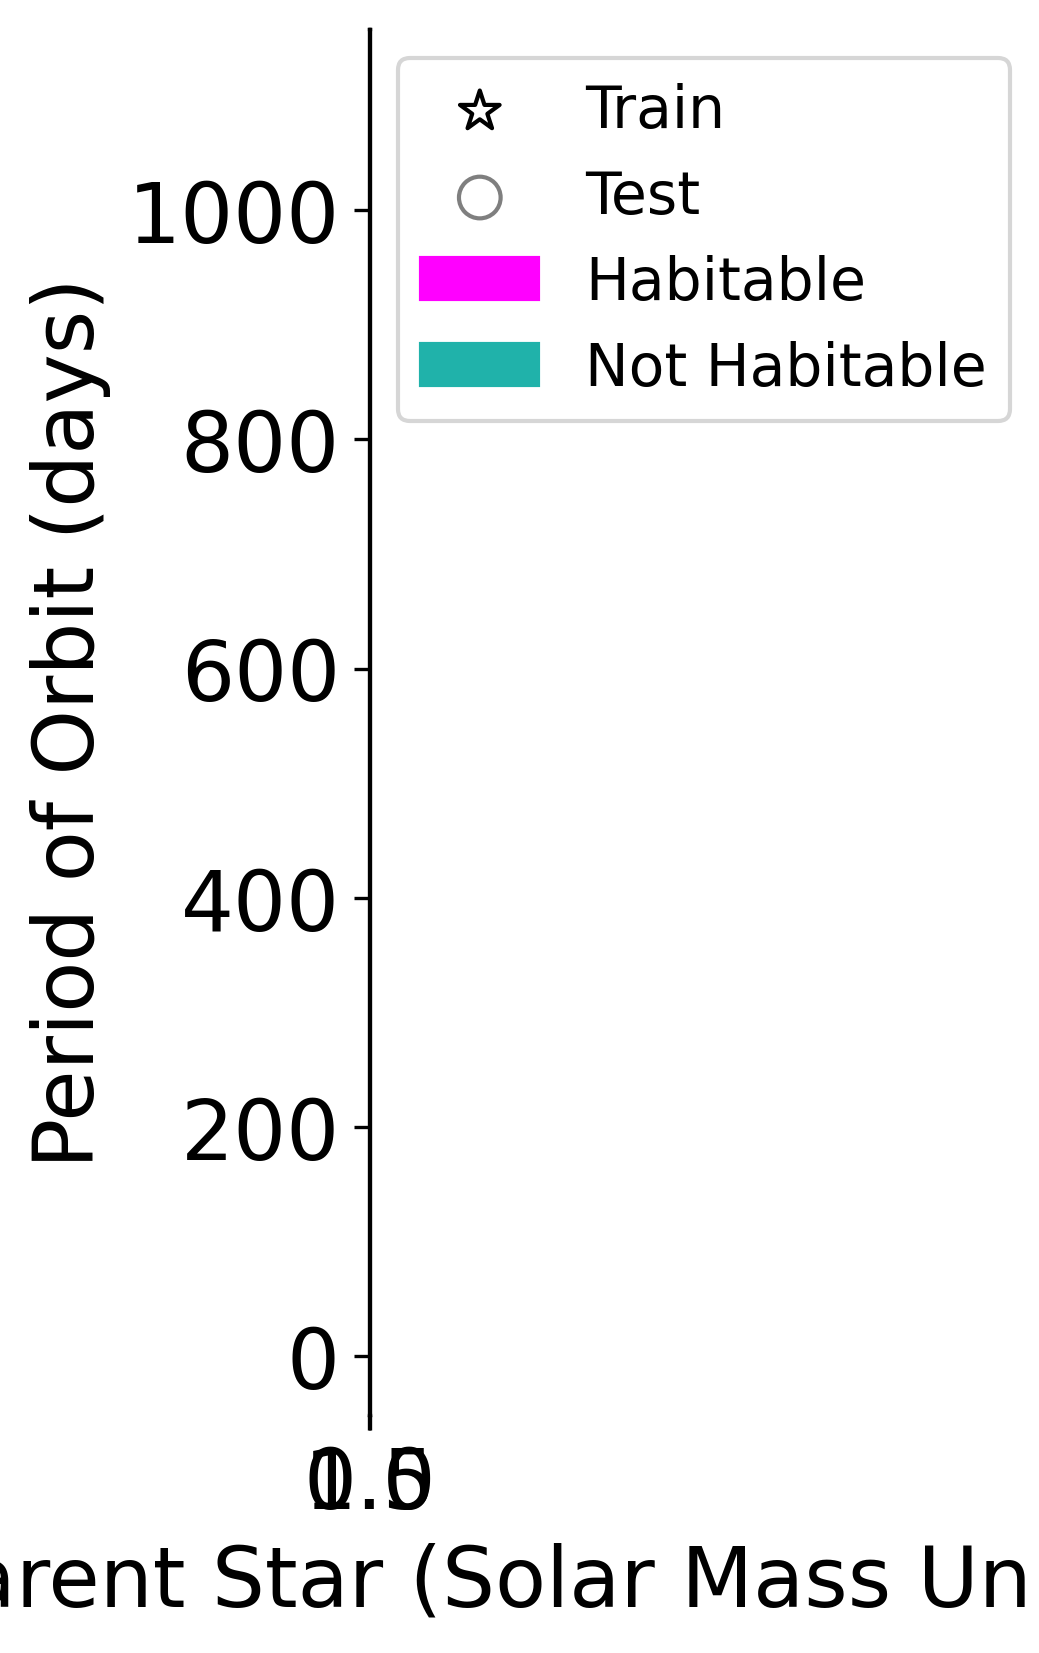

In [102]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap)

#a.set_facecolor('none')


a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5)

#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),knn_model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

# Removed hardcoded xlim and ylim to allow automatic scaling
# plt.xlim(-130,70)
# plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#plt.savefig('HabPlanetsKNN2features.png', dpi = 300)

### Nota algo particular en el gráfico?

Sí, las regiones de vecinos cercanos aparecen distorsionadas, especialmente en el eje del período orbital.


 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [103]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [104]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

RobustScaler()

In [105]:
scaledXTrain = scaler.transform(Xtrain)

In [106]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [107]:
scaledXtest = scaler.transform(Xtest) #

In [108]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

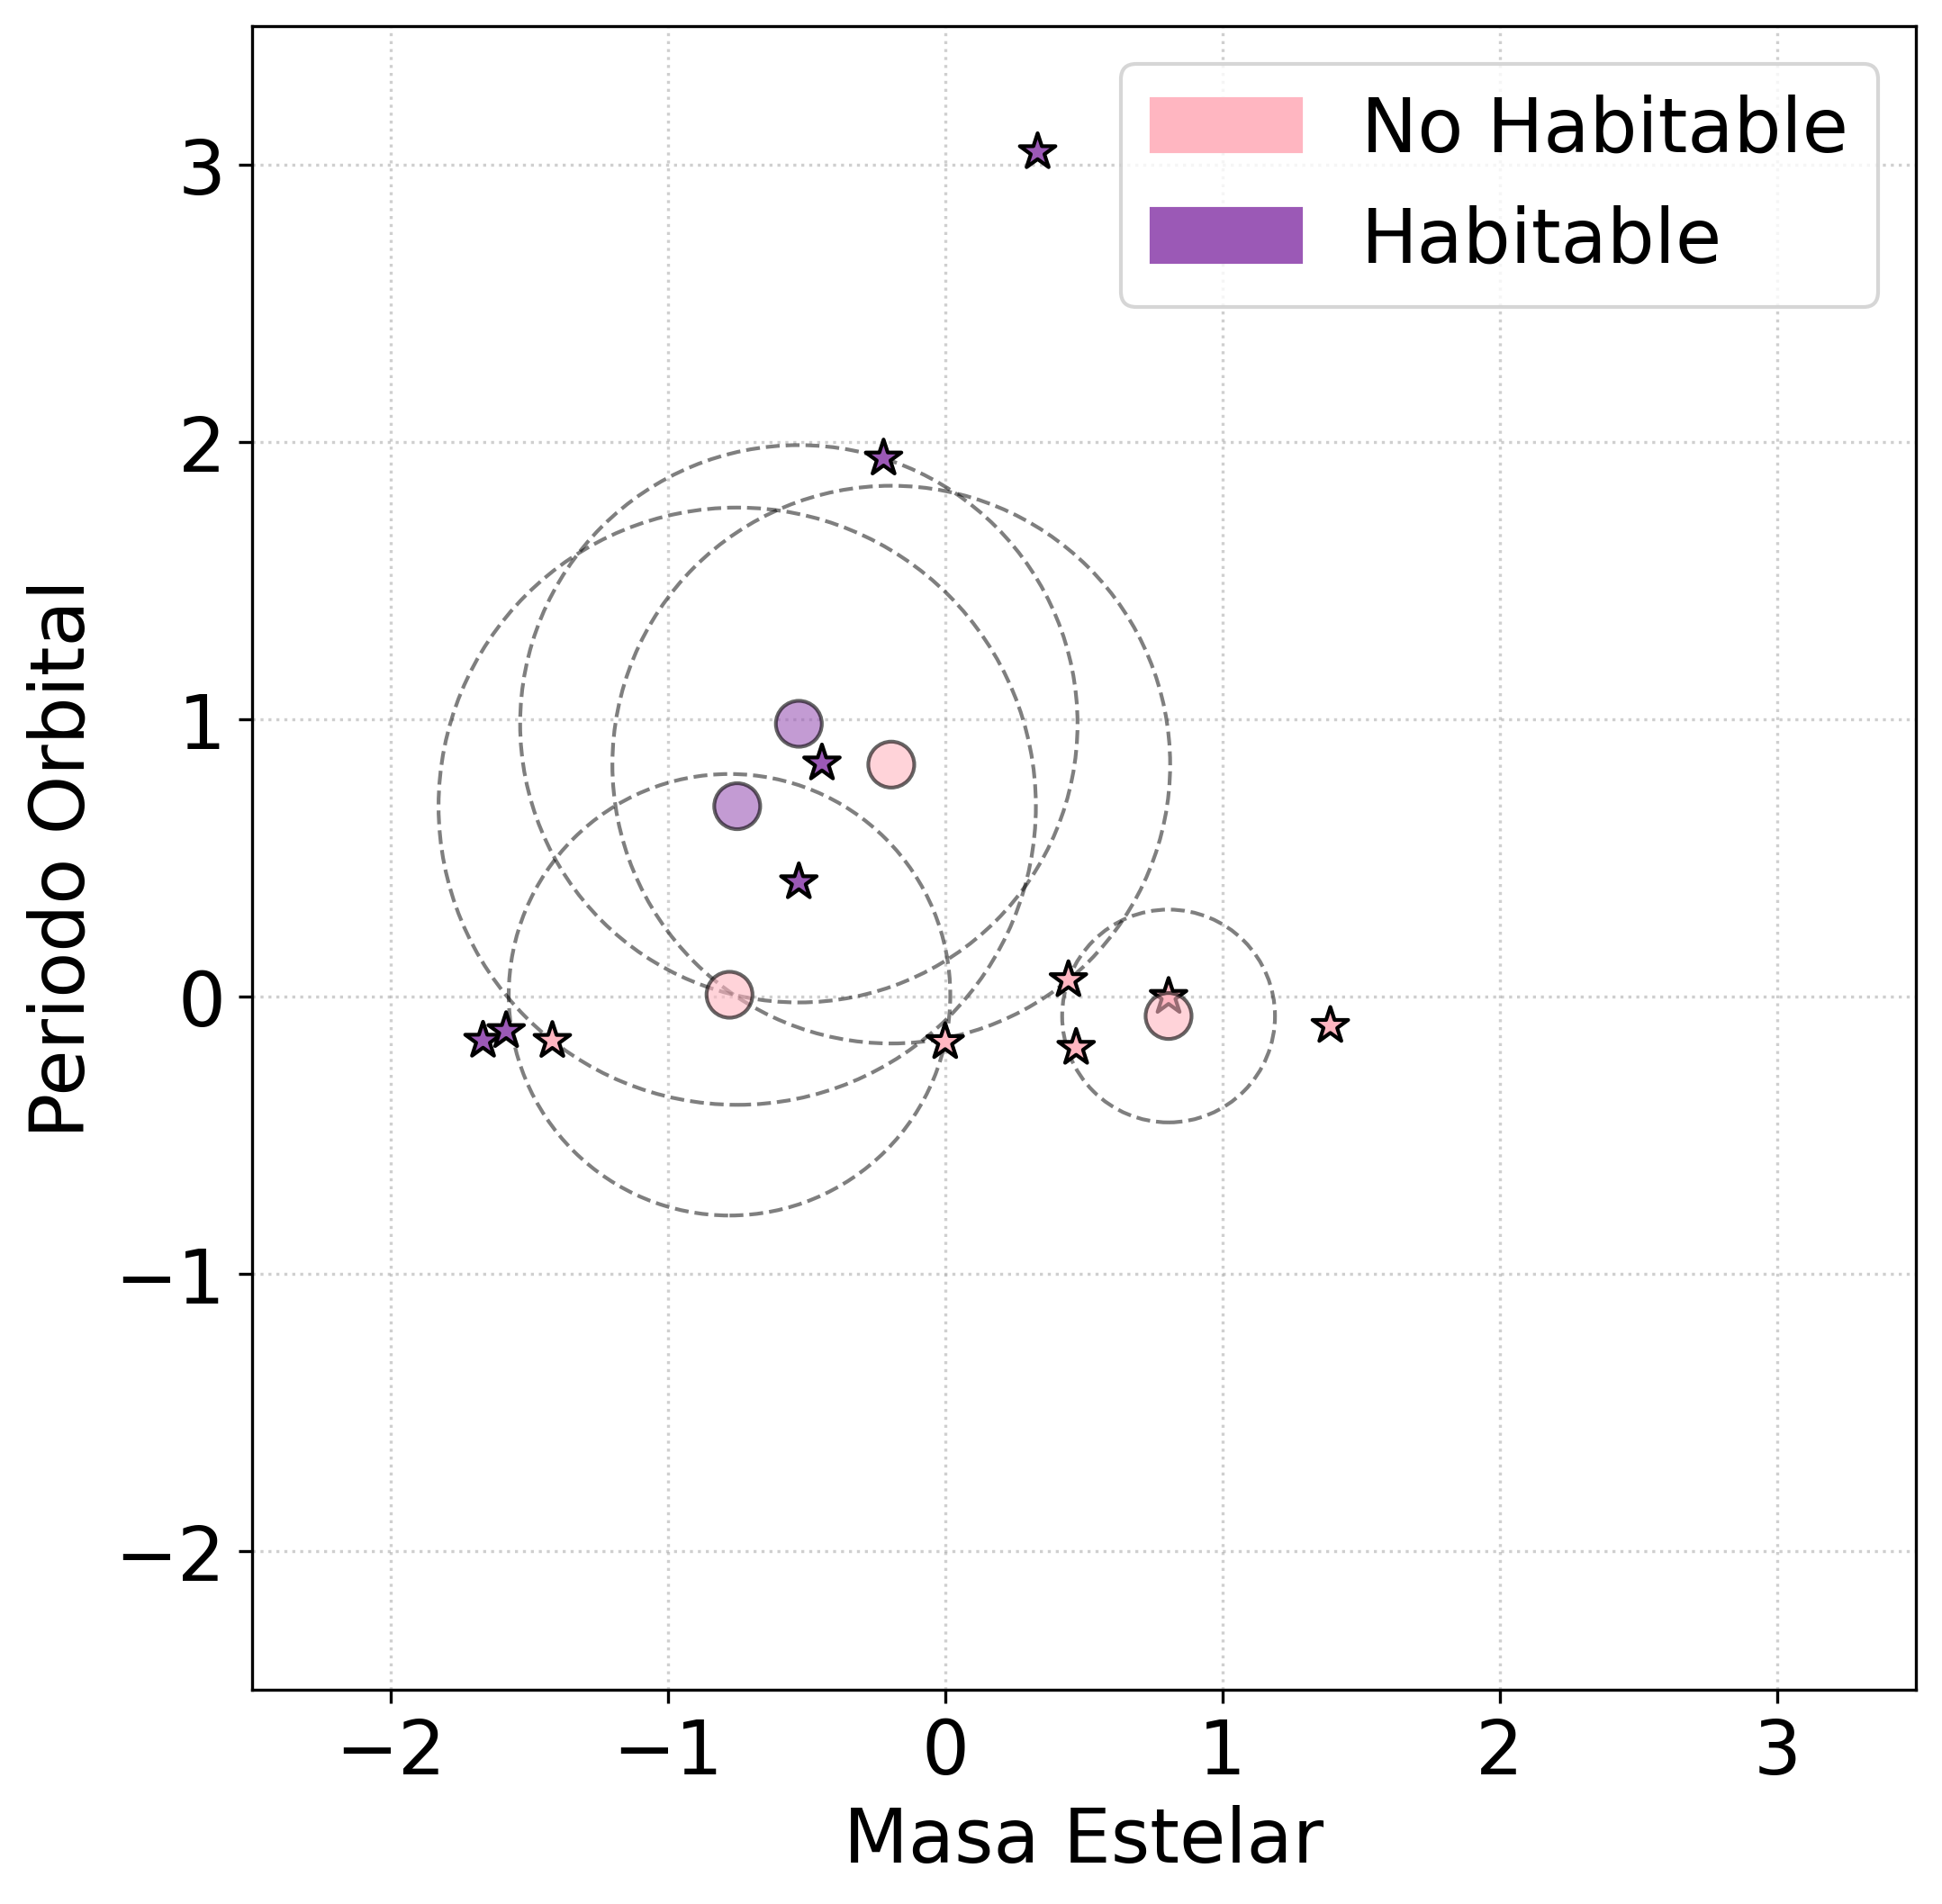

In [115]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.colors as mcolors

model_2d = KNeighborsClassifier(n_neighbors=3)
model_2d.fit(scaledXTrain[:, :2], ytrain)
distances, indices = model_2d.kneighbors(scaledXtest[:, :2])

# Visualización
fig, ax = plt.subplots(figsize=(8, 8))
cmap = mcolors.LinearSegmentedColormap.from_list("",["#FFB6C1", "#9B59B6"])

ax.scatter(scaledXTrain[:, 0], scaledXTrain[:, 1], marker='*', facecolor='None',
           c=ytrain, s=100, label='Train', cmap=cmap, edgecolors='k', zorder=3)

ax.scatter(scaledXtest[:, 0], scaledXtest[:, 1], marker='o', facecolor='None',
           c=ytest, s=150, label='Test', cmap=cmap, alpha=0.6, edgecolors='k', zorder=4)

for i in range(len(scaledXtest)):
    centro = (scaledXtest[i, 0], scaledXtest[i, 1])
    radio = distances[i, 2]
    circle = plt.Circle(centro, radio, lw=1, edgecolor='black', facecolor='none',
                        linestyle='--', alpha=0.5, zorder=2)
    ax.add_artist(circle)

ax.set_xlim(-2.5, 3.5)
ax.set_ylim(-2.5, 3.5)

ax.set_aspect('equal', adjustable='box')

# Leyenda con colores consistentes
pink_patch = mpatches.Patch(color='#FFB6C1', label='No Habitable')
purple_patch = mpatches.Patch(color='#9B59B6', label='Habitable')
ax.legend(handles=[pink_patch, purple_patch], loc='upper right')

ax.set_xlabel('Masa Estelar')
ax.set_ylabel('Periodo Orbital')
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [117]:
knn_model_all_features = neighbors.KNeighborsClassifier(n_neighbors = 3)
knn_model_all_features.fit(scaledXTrain, ytrain)
ypred_scaled_knn_all_features = knn_model_all_features.predict(scaledXtest)
train_accuracy_scaled_knn_all_features = metrics.accuracy_score(ytrain, knn_model_all_features.predict(scaledXTrain))

print(f"Accuracy en el set de entrenamiento (kNN escalado, TODAS las features): {train_accuracy_scaled_knn_all_features:.2%}")
test_accuracy_scaled_knn_all_features = metrics.accuracy_score(ytest, ypred_scaled_knn_all_features)
print(f"Accuracy en el set de prueba (kNN escalado, TODAS las features): {test_accuracy_scaled_knn_all_features:.2%}")

Accuracy en el set de entrenamiento (kNN escalado, TODAS las features): 84.62%
Accuracy en el set de prueba (kNN escalado, TODAS las features): 80.00%


### Preguntas

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

- Compare las fortalezas y debilidades de DT y kNN

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?

1. No, los árboles de decisión no se ven afectados por la escala, mientras que kNN sí, porque se basa en distancias.

2. DT: interpretables y no requieren escalado, pero tienden a sobreajustarse.  
   kNN: simple y flexible, pero sensible a la escala y dependiente de k.

3. DT clasifica mediante reglas basadas en umbrales y kNN clasifica según los vecinos más cercanos.

4. No basta porque puede existir sobreajuste y el modelo no generalizar bien.

5. kNN requiere escalamiento porque usa distancias, DT no porque usa divisiones por umbrales.

6. Elegiría kNN escalado, ya que muestra un comportamiento más estable en este dataset pequeño.